In [7]:
import pandas as pd
from pathlib import Path
path = Path("Data")
path.mkdir(exist_ok=True)
df = pd.read_csv(path /"output.csv")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
df.head()

,PatientDurableKey,IndexEncounterKey,IndexOutpatientDate,IndexDepartmentKey,IndexDepartmentName,IndexDiagnosisKey,IndexDiagnosisName,IndexDiagnosisValue,IndexGroupCode,IndexGroupName,IndexEncounterType,IndexVisitType,IndexVisitTypeDescription,CensusTract,FirstRace,MaritalStatus,MyChartStatus,OmbEthnicity,OmbRace,PatientBirthYearBin,SexAssignedAtBirth,SexualOrientation,SmokingStatus,VitalStatus,DataEndDate,DaysObservedAfterIndex,CanObserve180Days,SecondOutpatientDate,DaysToSecondOutpatient,FirstEDDate,DaysToFirstED,FirstInpatientDate,DaysToFirstInpatient,EDBeforeFollowup,InpatientBeforeFollowup,Broken180_NoTimelyFollowup,BrokenComposite_180_90
0,574989,101314041,2022-01-03,341,823 WOUNDCARE,911583,Type 2 diabetes mellitus with other skin ulcer...,E11.622,ICD-10-CM: E11,Type 2 diabetes mellitus,Office Visit,NEW PATIENT,Clinic Visits- In Person,2.017700e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-12-31,1458,1,2022-02-25,53.0,2022-03-16,72.0,2022-06-27,175.0,0,0,0.0,0.0
1,3102944,101273798,2022-01-03,341,823 WOUNDCARE,911583,Type 2 diabetes mellitus with other skin ulcer...,E11.622,ICD-10-CM: E11,Type 2 diabetes mellitus,Follow-Up,FOLLOW UP,Clinic Visits- In Person,2.017700e+10,White or Caucasian,Divorced,Activated,Not Hispanic or Latino,White,1945.0,*Unspecified,*Unspecified,Former,Alive,2025-12-31,1458,1,2022-02-04,32.0,2022-09-09,249.0,2022-05-24,141.0,0,0,0.0,0.0
2,6898291,90617718,2022-01-03,299,6TH FRAZIER ENDOCRINOLOGY,405570,Type 2 diabetes mellitus with hyperglycemia (H...,E11.65,ICD-10-CM: E11,Type 2 diabetes mellitus,Follow-Up,FOLLOW UP,Clinic Visits- In Person,2.017700e+10,White or Caucasian,Married,Activated,Not Hispanic or Latino,White,1975.0,Female,Straight,Never,Alive,2025-12-31,1458,1,2022-06-09,157.0,2025-10-05,1371.0,2025-10-05,1371.0,0,0,0.0,0.0
3,6641614,100295950,2022-01-03,10228,FOOT AND ANKLE CLINIC,455966,Type 2 diabetes mellitus with foot ulcer (Mult...,E11.621,ICD-10-CM: E11,Type 2 diabetes mellitus,Office Visit,FOLLOW UP,Clinic Visits- In Person,NaN,White or Caucasian,Single,Activated,Not Hispanic or Latino,White,1960.0,Female,*Unspecified,Never,Alive,2025-12-31,1458,1,2022-03-25,81.0,2023-04-10,462.0,2023-04-10,462.0,0,0,0.0,0.0
4,444911,98571084,2022-01-03,299,6TH FRAZIER ENDOCRINOLOGY,204307,Type 2 diabetes mellitus with other diabetic n...,E11.49,ICD-10-CM: E11,Type 2 diabetes mellitus,Follow-Up,FOLLOW UP,Clinic Visits- In Person,2.017700e+10,White or Caucasian,Single,Activated,Not Hispanic or Latino,White,1965.0,*Unspecified,*Unspecified,Never,Alive,2025-12-31,1458,1,2022-05-02,119.0,2023-04-26,478.0,NaN,NaN,0,0,0.0,0.0


In [3]:
df.columns

Index(['PatientDurableKey', 'IndexEncounterKey', 'IndexOutpatientDate',
       'IndexDepartmentKey', 'IndexDepartmentName', 'IndexDiagnosisKey',
       'IndexDiagnosisName', 'IndexDiagnosisValue', 'IndexGroupCode',
       'IndexGroupName', 'IndexEncounterType', 'IndexVisitType',
       'IndexVisitTypeDescription', 'CensusTract', 'FirstRace',
       'MaritalStatus', 'MyChartStatus', 'OmbEthnicity', 'OmbRace',
       'PatientBirthYearBin', 'SexAssignedAtBirth', 'SexualOrientation',
       'SmokingStatus', 'VitalStatus', 'DataEndDate', 'DaysObservedAfterIndex',
       'CanObserve180Days', 'SecondOutpatientDate', 'DaysToSecondOutpatient',
       'FirstEDDate', 'DaysToFirstED', 'FirstInpatientDate',
       'DaysToFirstInpatient', 'EDBeforeFollowup', 'InpatientBeforeFollowup',
       'Broken180_NoTimelyFollowup', 'BrokenComposite_180_90'],
      dtype='object')

In [4]:
df["BrokenComposite_180_90"].value_counts(normalize=True)

BrokenComposite_180_90
1.0    0.566376
0.0    0.433624
Name: proportion, dtype: float64

In [19]:
X = df[["IndexDepartmentName","IndexDiagnosisName","IndexDiagnosisValue","IndexEncounterType","IndexVisitType",
       "IndexVisitTypeDescription","CensusTract","FirstRace","MaritalStatus","MyChartStatus","PatientBirthYearBin","SexAssignedAtBirth",
       "SexualOrientation","SmokingStatus","VitalStatus"]]

In [15]:
import numpy as np
df = df.replace("NA", np.nan)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# split features
num_cols = X.select_dtypes(include=["number"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

# pipelines
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# combine
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

<Axes: >

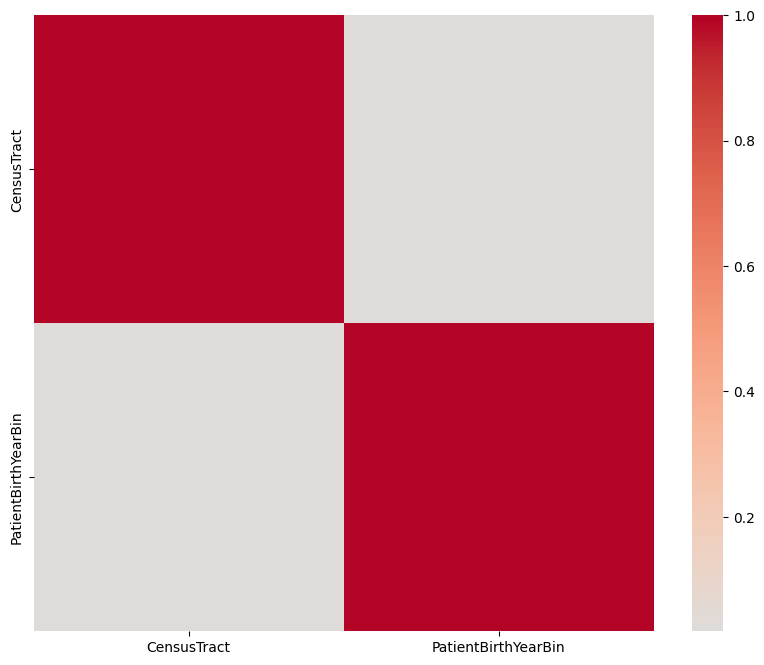

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = X.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)

In [18]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

X = df.drop(columns=["BrokenComposite_180_90"])
y = df["BrokenComposite_180_90"]

# You MUST encode categorical variables first
X_encoded = pd.get_dummies(X, drop_first=True)

mi = mutual_info_classif(X_encoded, y, random_state=42)

mi_series = pd.Series(mi, index=X_encoded.columns).sort_values(ascending=False)
import matplotlib.pyplot as plt

top_n = 20

mi_series.head(top_n).sort_values().plot(kind="barh")
plt.title("Top Mutual Information Features")
plt.xlabel("Mutual Information")
plt.tight_layout()
plt.show()

c:\Users\dilra\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\externals\array_api_compat\numpy\_aliases.py:125: RuntimeWarning: invalid value encountered in cast
  return x.astype(dtype=dtype, copy=copy)


ValueError: Input y contains NaN.